In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [19]:
df = pd.read_pickle('/home/paolo/Na_dataset/diffusion.pckl.gzip', compression='gzip')

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [20]:
df

,structure,atoms,D_sim,D_300K,Ea,D0,r,D_sim_std,atoms_diffusion,diffusion_temps,...,VPA,NBI,RBI,weighted_electronegativity,FV,Na_spacing,Na_former_ratio,Na_anion_ratio,log_conductivity,logD
0,"[[-40.55755644 -31.11690268 -12.78408373] Na, ...","(Atom('Na', [np.float64(-40.557556437030854), ...","[1.4364625631071203e-07, 1.951308390440328e-06...",0.0,0.41481,-6.168029,-0.999534,"[2.0609274977491014e-08, 9.54751980775219e-08,...","[(Atom('Na', [np.float64(16.4013), np.float64(...","[500, 700, 900, 1100]",...,30.092044,0.672310,3.270586,2.779514,16.271870,5.009553,0.818182,0.239362,-6.802830,-22.213615
1,"[[-27.22272146 -48.08938883 -1.16173696] Na, ...","(Atom('Na', [np.float64(-27.222721459416434), ...","[5.260053344200803e-08, 4.0005952618958283e-07...",0.0,0.342211,-8.892149,-0.998229,"[1.170380927951024e-08, 3.5028882907097395e-08...","[(Atom('Na', [np.float64(22.3934), np.float64(...","[500, 700, 900, 1100]",...,28.802260,0.534658,1.160079,2.334804,9.578810,4.023160,0.851852,0.442308,-6.060846,-22.129469
2,"[[ -8.75124573 -35.84817417 1.41113688] Na, ...","(Atom('Na', [np.float64(-8.751245728991412), n...","[4.1491531541234836e-07, 2.9527838854461532e-0...",0.0,0.309818,-7.538836,-0.999465,"[4.712111654890927e-08, 1.5290730622277523e-07...","[(Atom('Na', [np.float64(21.1725), np.float64(...","[500, 700, 900, 1100]",...,41.988188,0.418590,3.717974,2.110441,16.853349,4.911786,0.818182,0.387931,-4.053234,-19.523147
3,"[[ 5.90065301 -22.92956849 38.91278713] Na, ...","(Atom('Na', [np.float64(5.900653007410151), np...","[3.644390884127098e-07, 2.282692400171146e-06,...",0.0,0.336138,-7.142088,-0.995077,"[2.3186241807603783e-08, 7.300603522025543e-08...","[(Atom('Na', [np.float64(6.08525), np.float64(...","[500, 700, 900, 1100]",...,44.180268,0.459960,12.327698,1.925347,13.252481,3.934283,2.846154,0.725490,-4.008862,-20.144502
4,"[[-19.7964428 -12.94618545 -22.08417706] Na, ...","(Atom('Na', [np.float64(-19.79644280037215), n...","[6.07698230883191e-08, 2.0869815246937256e-07,...",0.0,0.364908,-8.508542,-0.964053,"[1.548478587054459e-08, 3.1640692055019905e-08...","[(Atom('Na', [np.float64(3.56707), np.float64(...","[500, 700, 900, 1100]",...,21.846223,0.603340,1.635307,2.640404,9.327898,4.334335,0.492537,0.268293,-6.778690,-22.623812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,"[[-45.16852818 -78.13919154 20.16465523] Na, ...","(Atom('Na', [np.float64(-45.16852817712178), n...","[3.297906167882209e-06, 1.8844573960753516e-05...",0.0,0.247734,-6.836898,-0.999179,"[9.792967224616881e-08, 3.9756638417401317e-07...","[(Atom('Na', [np.float64(21.5008), np.float64(...","[500, 700, 900, 1100]",...,51.279798,0.503579,9.309462,2.179317,22.017312,4.934985,1.828571,0.426667,-0.963887,-16.419663
1300,"[[ 27.78664333 -31.36783786 -24.2354884 ] Na, ...","(Atom('Na', [np.float64(27.786643333402175), n...","[9.156914520012137e-07, 5.1272087089512735e-06...",0.0,0.283584,-7.370918,-0.998882,"[4.870329640437488e-08, 1.4125831290277235e-07...","[(Atom('Na', [np.float64(-1.42491), np.float64...","[500, 700, 900, 1100]",...,47.672488,0.587851,2.941818,2.144747,15.234442,3.981873,2.846154,0.755102,-2.240883,-18.340452
1301,"[[ 9.75765064 -22.01865729 14.7129202 ] Na, ...","(Atom('Na', [np.float64(9.757650639408531), np...","[1.8383356363262403e-07, 1.3151544777712655e-0...",0.0,0.326622,-7.991634,-0.998646,"[1.634566553839534e-08, 5.978999364457793e-08,...","[(Atom('Na', [np.float64(10.255), np.float64(6...","[500, 700, 900, 1100]",...,42.832632,0.457983,1.896230,1.958541,11.402734,3.826133,1.857143,0.764706,-4.406686,-20.625948
1302,"[[-39.37930038 -62.24010789 -38.49384248] Na, ...","(Atom('Na', [np.float64(-39.37930038383808), n...","[8.887014627167615e-07, 6.4231800149440465e-06...",0.0,0.297862,-7.015121,-0.999876,"[4.980311200542334e-08, 2.1804315739470145e-07...","[(Atom('Na', [np.float64(22.5873), np.float64(...","[500, 700, 900, 1100]",...,39.816525,0.617591,3.275683,2.479636,17.560774,4.69335

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [4]:
df.columns

Index(['structure', 'atoms', 'D_sim', 'D_300K', 'Ea', 'D0', 'r', 'D_sim_std',
       'atoms_diffusion', 'diffusion_temps', 'formula', 'composition', 'B%',
       'N%', 'O%', 'F%', 'Na%', 'Al%', 'Si%', 'P%', 'S%', 'Cl%', 'Ge%', 'Br%',
       'I%', 'density', 'AAV', 'PF', 'SBI', 'VPA', 'NBI', 'RBI',
       'weighted_electronegativity', 'FV', 'Na_spacing', 'Na_former_ratio',
       'Na_anion_ratio', 'log_conductivity', 'logD'],
      dtype='object')

In [5]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
kb

8.617333262145179e-05

In [6]:
i = 0
D = np.array(df['D_sim'].str[i])[:500]
T = np.array(df['diffusion_temps'].str[i])[:500]
E = np.array(df['Ea'], dtype = 'float')[:500]/(kb*T)
D0 = np.array(df['D0'], dtype = 'float')[:500]

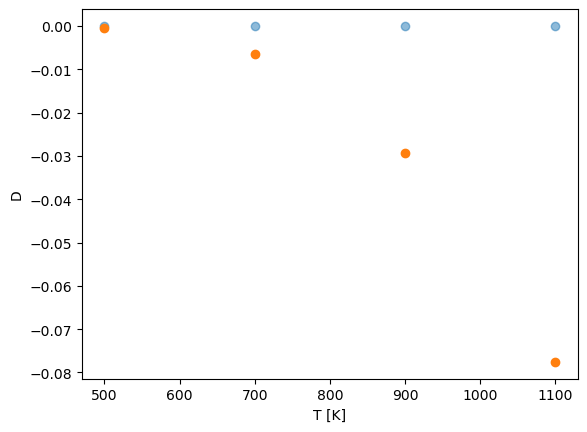

In [7]:
t_array = np.array(df['diffusion_temps'][0])
E0 = np.array(df['Ea'][0], dtype = 'float')/kb
plt.scatter(t_array , np.array(df['D_sim'][0]), alpha = 0.5)
plt.scatter(t_array , df['D0'][0]*np.exp(-E0/t_array))
plt.xlabel('T [K]')
plt.ylabel('D')
plt.show()

In [11]:
DvsE = pd.DataFrame({"sample_id": [f"s{i+1}" for i in range(len(D))], 'E/T': E, 'D': D})

In [12]:
DvsE.to_csv("/home/paolo/Thesis/Na/data/Na_diff.csv", index=False)
data_file = "/home/paolo/Thesis/Na/data/Na_diff.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [294]:
# Try the fit with the exact functional form
Diff_json = {
    'data_file': data_file,
     'property_key': 'D',
     'desc_dim': 1,
     'n_sis_select': 15,
     'max_rung': 2,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open("/home/paolo/Thesis/Na/data/diff.json", "w"), indent=4)

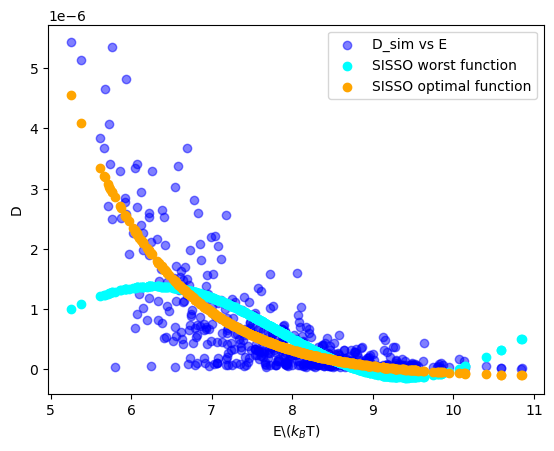

In [8]:
opt_funct = 1.704458640741253e-04*E/np.exp(E) - 1.390360191953970e-07
worst_funct = 7.570330401562866e-07*np.cos(E) +  6.191808278717039e-07 
plt.scatter(E , D, alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , worst_funct, color = 'cyan', label = 'SISSO worst function')
plt.scatter(E, opt_funct, label='SISSO optimal function', color = 'orange')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

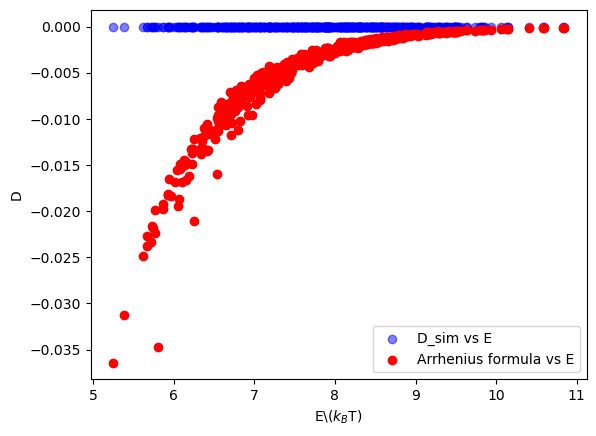

In [9]:
plt.scatter(E , D, alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , D0*np.exp(-E), color = 'red', label = 'Arrhenius formula vs E')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

In [9]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

In [18]:
model = PySRRegressor(
    niterations=500,
    populations=50,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "cos", "sin", "exp"],
    maxdepth = 2,
    #maxsize = 100
)
model.fit(E.reshape(-1, 1), D, variable_names=["E_T"])

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.090e+05
Progress: 4637 / 25000 total iterations (18.548%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.625e-13  0.000e+00  y = 6.2973e-07
3           6.519e-13  7.837e-02  y = 5.4301e-06 / E_T
4           2.394e-13  1.002e+00  y = 0.00097795 / exp(E_T)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.280e+05
Progress: 9128 / 25000 total iterations (36.512%)
════════════════════════════════════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['square', 'cos', ...]"
,expression_spec,None
,niterations,500
,populations,50
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,2
,warmup_maxsize_by,None


  - outputs/20251216_093102_ezbRUK/hall_of_fame.csv


In [19]:
model.sympy()

0.000977952/exp(E_T)

In [8]:
Ea = np.array(df['Ea'], dtype = 'float')[:500]
# SEED = 42
# np.random.seed(SEED)
# random.seed(SEED)
model2 = PySRRegressor(
    niterations=300,
    populations=50,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["cos", "sin", "exp"],
    maxdepth = 10,
    #maxsize = 100
)
model2.fit(Ea.reshape(-1, 1), D, variable_names=["Ea"])

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.300e+05
Progress: 1426 / 15000 total iterations (9.507%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.625e-13  0.000e+00  y = 6.2962e-07
3           6.519e-13  7.837e-02  y = 2.3394e-07 / Ea
5           3.416e-13  3.231e-01  y = (1.5663e-06 / Ea) + -4.0929e-06
6           2.864e-13  1.763e-01  y = 0.00017359 / exp(Ea / 0.058201)
7           2.511e-13  1.313e-01  y = (2.4429e-07 / (Ea + -0.18899)) - 1.2101e-06
8           2.380e-13  5.383e-02  y = (-2.3199e-05 / exp(Ea / 0.041618)) / -0.019046
12          2.369e-13  1.119e-03  y = (-0.00018945 / (Ea / (-0.072474 / Ea))) / exp(Ea / 0.0...
                                      58201)
14          2.367e-13  4.168e-04  y = ((-0.00018945 / (Ea / -0.072474)) / (exp(Ea / 0.058201...
               

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['cos', 'sin', ...]"
,expression_spec,None
,niterations,300
,populations,50
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,10
,warmup_maxsize_by,None


Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [10]:
sympy.simplify(model2.sympy())

0.0019560584*exp(-25.7629703674315*Ea)

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [16]:
model2.get_best()

complexity                                                     6
loss                                                         0.0
equation                      0.0019560584 / exp(Ea / 0.0388154)
score                                                   0.336828
sympy_format                      0.0019560584/exp(Ea/0.0388154)
lambda_format    PySRFunction(X=>0.0019560584/exp(Ea/0.0388154))
Name: 3, dtype: object

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [17]:
1/0.0388154

25.762970367431482

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [10]:
1/(kb*500)

23.20903624310016

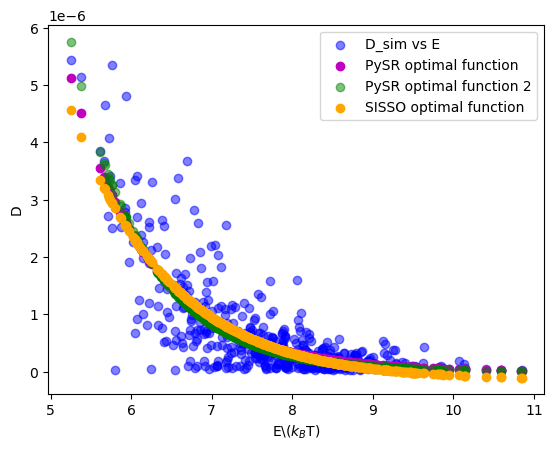

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [18]:
opt_funct = 1.704458640741253e-04*E/np.exp(E) - 1.390360191953970e-07
pysr_fuct =  0.000977952*np.exp(-E)
pysr_fuct2 =  0.0019560584*np.exp(-25.762970367431482*Ea)
plt.scatter(E , D, alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , pysr_fuct, color = 'm', label = 'PySR optimal function')
plt.scatter(E , pysr_fuct2, alpha = 0.5, color = 'g', label = 'PySR optimal function 2')
plt.scatter(E, opt_funct, label='SISSO optimal function', color = 'orange')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()